# themis-asi-search quickstart

This notebook demonstrates the use of the query function to find images similar to a user-specified query image. At a minimum, the query must specify `(site, datetime, frame)` and it will return a table with the 24 most similar images in the database. Point `ARTIFACTS` at a directory containing `index.faiss`, `manifest.parquet`, `vectors.f16.dat`, and `vectors.meta.json`.

In [1]:
import sys
sys.path.append('/home/jeremiah/projects/themis-similarity-search/themis-asi-search')

from themisim import query

ARTIFACTS = "./artifacts"  # <-- edit to your index location

The first query may take some extra time loading the engine.

In [2]:
df = query("fsmi", "2015-03-18T06", 412, artifacts=ARTIFACTS)
df

,site,datetime,score,source_cdf
0,fsmi,2015-03-18 06:20:36 UTC,1.000000,http://themis.ssl.berkeley.edu/data/themis/thg...
1,fsmi,2015-03-18 06:21:09 UTC,0.980023,http://themis.ssl.berkeley.edu/data/themis/thg...
2,fsmi,2015-03-18 06:21:42 UTC,0.970359,http://themis.ssl.berkeley.edu/data/themis/thg...
3,fykn,2015-03-23 08:40:06 UTC,0.964877,http://themis.ssl.berkeley.edu/data/themis/thg...
4,fykn,2015-03-23 08:39:36 UTC,0.964503,http://themis.ssl.berkeley.edu/data/themis/thg...
5,fykn,2015-03-19 06:48:30 UTC,0.963546,http://themis.ssl.berkeley.edu/data/themis/thg...
6,fykn,2015-03-19 06:44:42 UTC,0.962412,http://themis.ssl.berkeley.edu/data/themis/thg...
7,fsmi,2010-04-07 06:11:36 UTC,0.961552,http://themis.ssl.berkeley.edu/data/themis/thg...
8,fsmi,2015-09-21 05:23:45 UTC,0.959554,http://themis.ssl.berkeley.edu/data/themis/thg...
9,inuv,2014-01-04 05:26:09 UTC,0.959192,http://themis.ssl.berkeley.edu/data/themis/thg...


The engine is cached per artifacts directory, so while the first query will take some time subsequent queries are much faster. 

In [3]:
%%timeit 

df = query("fsmi", "2015-03-18T06", 412, artifacts=ARTIFACTS)

99.7 ms ± 3.86 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Tune the query using the parameters described in the paper:

In [4]:
query(
    "fsmi", "2015-03-18T06", 412,
    artifacts=ARTIFACTS,
    results=12,
    prefilter=1000,
    nprobe=128,
    diversify_seconds=0,   # keep adjacent near-duplicate frames
)

,site,datetime,score,source_cdf
0,fsmi,2015-03-18 06:20:36 UTC,1.000000,http://themis.ssl.berkeley.edu/data/themis/thg...
1,fsmi,2015-03-18 06:20:33 UTC,0.997783,http://themis.ssl.berkeley.edu/data/themis/thg...
2,fsmi,2015-03-18 06:20:39 UTC,0.997385,http://themis.ssl.berkeley.edu/data/themis/thg...
3,fsmi,2015-03-18 06:20:42 UTC,0.995773,http://themis.ssl.berkeley.edu/data/themis/thg...
4,fsmi,2015-03-18 06:20:30 UTC,0.995512,http://themis.ssl.berkeley.edu/data/themis/thg...
5,fsmi,2015-03-18 06:20:45 UTC,0.994679,http://themis.ssl.berkeley.edu/data/themis/thg...
6,fsmi,2015-03-18 06:20:48 UTC,0.992942,http://themis.ssl.berkeley.edu/data/themis/thg...
7,fsmi,2015-03-18 06:20:54 UTC,0.990746,http://themis.ssl.berkeley.edu/data/themis/thg...
8,fsmi,2015-03-18 06:20:27 UTC,0.990605,http://themis.ssl.berkeley.edu/data/themis/thg...
9,fsmi,2015-03-18 06:20:51 UTC,0.990469,http://themis.ssl.berkeley.edu/data/themis/thg...


Visualize the results.

/home/jeremiah/anaconda3/envs/pytorch/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /home/jeremiah/anaconda3/envs/pytorch/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


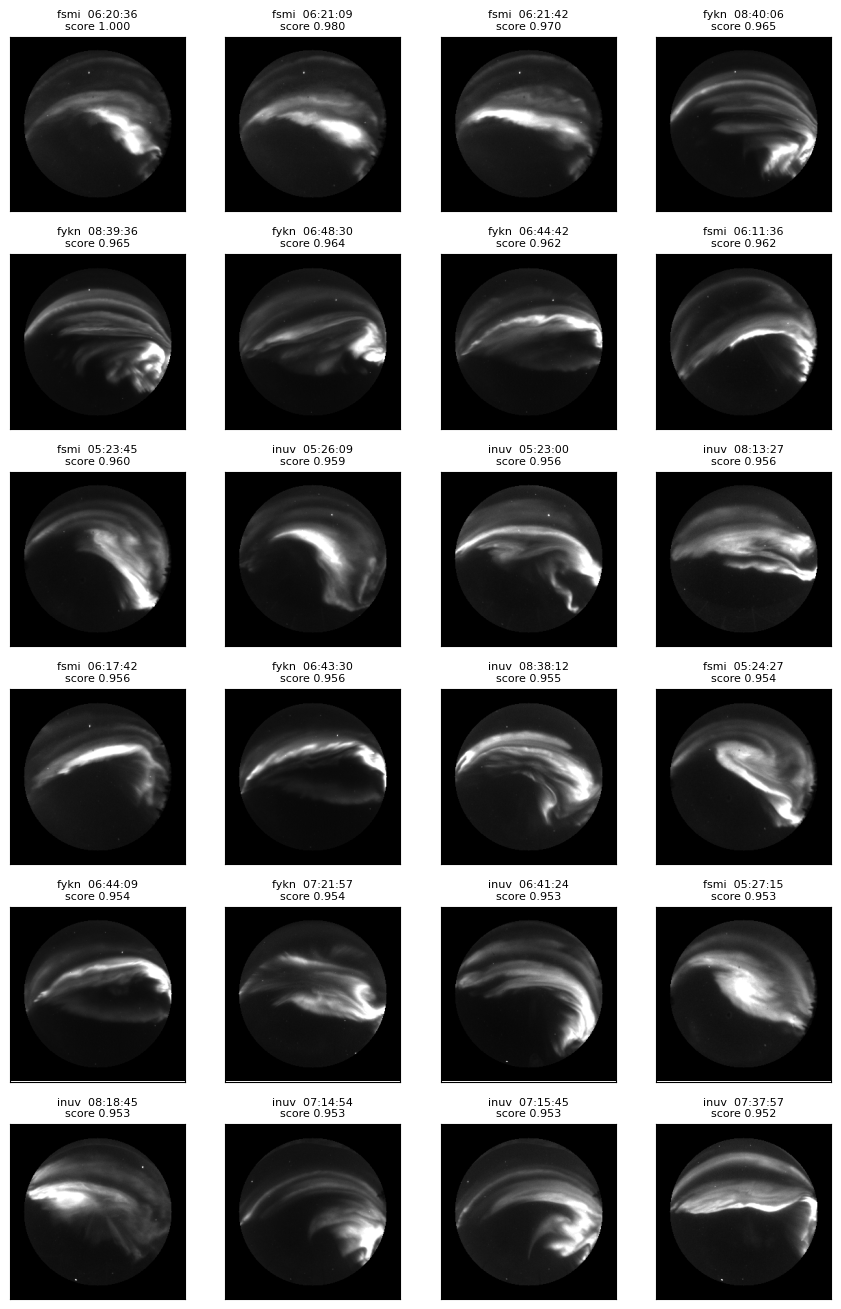

In [5]:
from themisim import visualize_results

# The source CDFs are fetched from the THEMIS archive on first use 
# (cached locally); pass data_root=... to read them from a local 
# mirror instead.
fig = visualize_results(df, cols=4)

In [ ]:
# Save to CSV
df.to_csv("results.csv", index=False)